<a href="https://colab.research.google.com/github/BarshaPanthi7/Danphe_task_Barsha/blob/main/notebooks/03_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

iemocap dataset eda

environment setup

In [2]:
import sys
print("Python version:", sys.version)

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


kaggle api configuration

In [ ]:
from google.colab import files

#uploading the kaggle api key
files.upload()

In [ ]:
import os
import shutil

# Creating Kaggle configuration directory
os.makedirs("/root/.config/kaggle", exist_ok=True)

# Moving the API key to the required location
shutil.move(
    "/content/kaggle.json",
    "/root/.config/kaggle/kaggle.json"
)

# Setting secure permissions
os.chmod(
    "/root/.config/kaggle/kaggle.json",
    0o600
)

print("Kaggle API configured successfully.")

upgrading kaggle cli

In [5]:
!pip install -q --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 2.9 MB/s eta 0:00:00


In [6]:
!kaggle --version

Kaggle CLI 2.2.4


searching for iemocap in kaggle

In [ ]:
from google.colab import userdata

KAGGLE_API_TOKEN = userdata.get("KAGGLE_API_TOKEN")

print("Kaggle token loaded:", bool(KAGGLE_API_TOKEN))

In [8]:
import os

os.environ["KAGGLE_API_TOKEN"] = KAGGLE_API_TOKEN

In [9]:
!kaggle datasets list -s iemocap

ref                                                       title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------  -------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
columbine/iemocap                                         IEMOCAP                                               10116183  2020-12-17 01:45:18.677000           3366         34  0.875            
dejolilandry/iemocapfullrelease                           Iemocap-full-release                               12384401065  2022-01-01 14:28:10.087000           6689         35  0.375            
samuelsamsudinng/iemocap-emotion-speech-database          IEMOCAP Emotion Speech Database                          36658  2020-12-14 14:16:54.373000           5601         31  0.47058824       
mouadriali/iemocap-transcripti

In [10]:
!kaggle datasets files -d dejolilandry/iemocapfullrelease --page-size 200

Next Page Token = CfDJ8GNxPX3qpaJEpxfoBSRBZPdXn-DxmZ6YZ_Zjpw479SVCzk3McYZuumAGHUNpCNmEVNE8glYBJVja66sUy1GlXWkojwjToN-KFx-yVuOHq9TkPYpnIf7LN36AKd61wzS0ENxuM9UgLRa0CEDbELRodGO0-xarj6NVvuk-D-_73uo6Lo-Jg5NPxvZG6Wu3SMa98o2y8xIqjNMC5Wd_PXYpga86Eoe1Eg-S6QWRkKdrDSHhzvM
name                                                                                            size  creationDate                
-------------------------------------------------------------------------------------------  -------  --------------------------  
IEMOCAP_full_release/Documentation/FIVE_face_markers2.png                                     437923  2022-01-01 14:32:08.773000  
IEMOCAP_full_release/Documentation/HumaineInfo.txt                                               555  2022-01-01 14:32:08.917000  
IEMOCAP_full_release/Documentation/corpus.dic                                                6696895  2022-01-01 14:32:08.895000  
IEMOCAP_full_release/Documentation/phonemes.txt                                    

In [11]:

import kagglehub
path = kagglehub.dataset_download(
    "dejolilandry/iemocapfullrelease"
)

Using Colab cache for faster access to the 'iemocapfullrelease' dataset.


In [12]:
!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  19% /


In [13]:
import os

print("Dataset path:", path)

print("\nContents of dataset:")

for item in os.listdir(path):
    print(item)

Dataset path: /kaggle/input/iemocapfullrelease

Contents of dataset:
IEMOCAP_full_release


In [14]:
# Defining the main IEMOCAP directory
iemocap_path = os.path.join(path, "IEMOCAP_full_release")

print("IEMOCAP path:", iemocap_path)

print("\nContents of IEMOCAP_full_release:")

for item in os.listdir(iemocap_path):
    print(item)

IEMOCAP path: /kaggle/input/iemocapfullrelease/IEMOCAP_full_release

Contents of IEMOCAP_full_release:
Session4
Session5
Documentation
Session1
Session3
Session2


checking the content of each session

In [15]:
# Checking the contents of each session

sessions = [
    "Session1",
    "Session2",
    "Session3",
    "Session4",
    "Session5"
]

for session in sessions:
    session_path = os.path.join(iemocap_path, session)

    print(f"\n{session}:")
    for item in os.listdir(session_path):
        print("  ", item)


Session1:
   sentences
   dialog

Session2:
   sentences
   dialog

Session3:
   sentences
   dialog

Session4:
   sentences
   dialog

Session5:
   sentences
   dialog


In [16]:
# Inspecting the contents of sentences and dialog for each session

for session in sessions:
    session_path = os.path.join(iemocap_path, session)

    print(f"\n{session}")

    for folder in ["sentences", "dialog"]:
        folder_path = os.path.join(session_path, folder)

        print(f"  {folder}:")
        for item in os.listdir(folder_path):
            print(f"    {item}")


Session1
  sentences:
    MOCAP_head
    ForcedAlignment
    MOCAP_hand
    MOCAP_rotated
    wav
  dialog:
    MOCAP_head
    EmoEvaluation
    MOCAP_hand
    MOCAP_rotated
    avi
    lab
    wav
    transcriptions

Session2
  sentences:
    MOCAP_head
    ForcedAlignment
    MOCAP_hand
    MOCAP_rotated
    wav
  dialog:
    MOCAP_head
    EmoEvaluation
    MOCAP_hand
    MOCAP_rotated
    lab
    wav
    transcriptions

Session3
  sentences:
    MOCAP_head
    ForcedAlignment
    MOCAP_hand
    MOCAP_rotated
    wav
  dialog:
    MOCAP_head
    EmoEvaluation
    MOCAP_hand
    MOCAP_rotated
    lab
    wav
    transcriptions

Session4
  sentences:
    MOCAP_head
    ForcedAlignment
    MOCAP_hand
    MOCAP_rotated
    wav
  dialog:
    MOCAP_head
    EmoEvaluation
    MOCAP_hand
    MOCAP_rotated
    lab
    wav
    transcriptions

Session5
  sentences:
    MOCAP_head
    ForcedAlignment
    MOCAP_hand
    MOCAP_rotated
    wav
  dialog:
    MOCAP_head
    EmoEvaluation
    MOCAP_

## Exploring Emotion and Transcription Data

Each session contains an `EmoEvaluation` folder and a `transcriptions`
folder inside the `dialog` directory.

`EmoEvaluation` contains emotional annotations, while `transcriptions`
contains the corresponding spoken utterances.

We will first check the number of files available in these folders
across all five sessions.

data profiling

In [23]:
import re
import os
import pandas as pd

emo_records = []

# Regex for EmoEvaluation lines, e.g.:
# [6.2901 - 8.2357]	Ses01F_impro01_F000	neu	[2.5, 2.5, 2.5]
emo_regex = r'\[(\d+\.\d+) - (\d+\.\d+)\]\s+(\S+)\s+(\w+)\s+\[([\d.,\s]+)\]'

for session in sessions:
    emo_path = os.path.join(iemocap_path, session, 'dialog', 'EmoEvaluation')
    if not os.path.exists(emo_path):
        print(f"Warning: EmoEvaluation path not found for {session}")
        continue

    # Only the top-level .txt files here hold the final emotion labels
    # (Categorical/ and Attribute/ subfolders hold raw per-annotator data, skip those)
    for file_name in os.listdir(emo_path):
        file_path = os.path.join(emo_path, file_name)
        if os.path.isfile(file_path) and file_name.endswith('.txt'):
            with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                for line in f:
                    match = re.match(emo_regex, line)
                    if match:
                        start, end, utt_id, emotion, vad = match.groups()
                        valence, arousal, dominance = [float(x) for x in vad.split(',')]
                        emo_records.append({
                            'utterance_id': utt_id,
                            'emotion': emotion,
                            'valence': valence,
                            'arousal': arousal,
                            'dominance': dominance
                        })

emo_df = pd.DataFrame(emo_records)
print("Emotion records parsed:", emo_df.shape)
display(emo_df.head())

# Merge emotion labels into the main transcription DataFrame using utterance_id as key
# df = df.drop(columns=['emotion'])  # This line is not needed as 'df' from transcription does not have 'emotion' column yet
df = df.merge(emo_df, on='utterance_id', how='left')

print("\nFinal merged shape:", df.shape)
display(df.head())

Emotion records parsed: (10039, 5)


,utterance_id,emotion,valence,arousal,dominance
0,Ses01M_script01_3_F000,neu,4.0,2.0,2.5
1,Ses01M_script01_3_F001,neu,4.0,2.0,2.5
2,Ses01M_script01_3_F002,xxx,4.0,2.0,2.0
3,Ses01M_script01_3_F003,sad,4.0,1.5,2.5
4,Ses01M_script01_3_F004,neu,3.5,2.0,2.5



Final merged shape: (10087, 10)


,session,utterance_id,start_time,end_time,speaker,text,emotion,valence,arousal,dominance
0,Ses01,Ses01M_script01_3_F000,8.2904,11.9425,M,The only one I know still love his parents.,neu,4.0,2.0,2.5
1,Ses01,Ses01M_script01_3_M000,11.8600,15.1286,M,"Yeah, that kind of went out of style didn't it?",hap,4.0,2.0,1.5
2,Ses01,Ses01M_script01_3_F001,14.5812,20.0400,M,Oh it's not bad thing it's good thing.,neu,4.0,2.0,2.5
3,Ses01,Ses01M_script01_3_F002,20.7769,27.6000,M,"You know it's nice here, the air is sweet.",xxx,4.0,2.0,2.0
4,Ses01,Ses01M_script01_3_M001,28.1000,30.5850,M,You're not sorry you came?,hap,3.5,3.0,1.5


In [22]:
transcription_records = []

# Regex for transcription lines, e.g.:
# Ses01F_impro01_F000 [ 0.0000 - 0.7000 ]: That's a good idea.
# The actual format from kernel state variable `line` is: 'Ses05F_impro07_F039 [179.6000-180.7600]: exciting.\n'
# Modified regex for more robustness:
#   - `\s*-\s*` allows flexible whitespace around the hyphen.
#   - `:?` makes the colon before the text optional.
trans_regex = r'(\S+)\s*\[\s*(\d+\.\d+)\s*-\s*(\d+\.\d+)\s*\]\s*:?\s*(.*)'

for session in sessions:
    trans_path = os.path.join(iemocap_path, session, 'dialog', 'transcriptions')
    if not os.path.exists(trans_path):
        print(f"Warning: Transcription path not found for {session}")
        continue

    for file_name in os.listdir(trans_path):
        # Construct the full file path for the current file
        file_path = os.path.join(trans_path, file_name)

        # We only care about the actual transcription files, not directories or other file types
        if os.path.isfile(file_path) and file_name.endswith('.txt'):
            with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                for line in f:
                    match = re.match(trans_regex, line)
                    if match:
                        utt_id, start_time, end_time, text = match.groups()

                        # Extract session from utterance_id (e.g., Ses01F_impro01_F000 -> Ses01)
                        # The format is typically SesXX_...
                        session_name_from_id = utt_id[:5] # e.g., 'Ses01'

                        # Extract speaker gender (F or M) from utterance_id (e.g., Ses01F...)
                        # Character at index 5 is F or M
                        speaker_gender = utt_id[5]

                        transcription_records.append({
                            'session': session_name_from_id,
                            'utterance_id': utt_id,
                            'start_time': float(start_time),
                            'end_time': float(end_time),
                            'speaker': speaker_gender,
                            'text': text.strip()
                        })

df = pd.DataFrame(transcription_records)
print("Transcription records parsed:", df.shape)
display(df.head())

Transcription records parsed: (10087, 6)


,session,utterance_id,start_time,end_time,speaker,text
0,Ses01,Ses01M_script01_3_F000,8.2904,11.9425,M,The only one I know still love his parents.
1,Ses01,Ses01M_script01_3_M000,11.8600,15.1286,M,"Yeah, that kind of went out of style didn't it?"
2,Ses01,Ses01M_script01_3_F001,14.5812,20.0400,M,Oh it's not bad thing it's good thing.
3,Ses01,Ses01M_script01_3_F002,20.7769,27.6000,M,"You know it's nice here, the air is sweet."
4,Ses01,Ses01M_script01_3_M001,28.1000,30.5850,M,You're not sorry you came?


In [24]:
# Now you can use df.shape
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (10087, 10)


In [25]:
print("Total rows:",df.shape[0])

Total rows: 10087


In [26]:
print("Total columns:", df.shape[1])

Total columns: 10


In [27]:
print("\nColumn names and data types:")
print(df.dtypes)


Column names and data types:
session          object
utterance_id     object
start_time      float64
end_time        float64
speaker          object
text             object
emotion          object
valence         float64
arousal         float64
dominance       float64
dtype: object


In [28]:
print("\nGeneral info:")
df.info()


General info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10087 entries, 0 to 10086
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   session       10087 non-null  object 
 1   utterance_id  10087 non-null  object 
 2   start_time    10087 non-null  float64
 3   end_time      10087 non-null  float64
 4   speaker       10087 non-null  object 
 5   text          10087 non-null  object 
 6   emotion       10039 non-null  object 
 7   valence       10039 non-null  float64
 8   arousal       10039 non-null  float64
 9   dominance     10039 non-null  float64
dtypes: float64(5), object(5)
memory usage: 788.2+ KB


In [29]:
print("\nFirst 5 rows:")
display(df.head())


First 5 rows:


,session,utterance_id,start_time,end_time,speaker,text,emotion,valence,arousal,dominance
0,Ses01,Ses01M_script01_3_F000,8.2904,11.9425,M,The only one I know still love his parents.,neu,4.0,2.0,2.5
1,Ses01,Ses01M_script01_3_M000,11.8600,15.1286,M,"Yeah, that kind of went out of style didn't it?",hap,4.0,2.0,1.5
2,Ses01,Ses01M_script01_3_F001,14.5812,20.0400,M,Oh it's not bad thing it's good thing.,neu,4.0,2.0,2.5
3,Ses01,Ses01M_script01_3_F002,20.7769,27.6000,M,"You know it's nice here, the air is sweet.",xxx,4.0,2.0,2.0
4,Ses01,Ses01M_script01_3_M001,28.1000,30.5850,M,You're not sorry you came?,hap,3.5,3.0,1.5


In [30]:
print("\nLast 5 rows:")
display(df.tail())


Last 5 rows:


,session,utterance_id,start_time,end_time,speaker,text,emotion,valence,arousal,dominance
10082,Ses05,Ses05F_impro07_F037,174.6500,175.73,F,yeah.,exc,4.0,2.5,2.5
10083,Ses05,Ses05F_impro07_M035,175.5500,178.95,F,"Good. We'll have to have one soon, you're goi...",exc,3.5,3.0,3.5
10084,Ses05,Ses05F_impro07_F038,177.2100,179.14,F,Woo-,exc,4.5,3.5,4.0
10085,Ses05,Ses05F_impro07_M036,179.0466,185.33,F,"Oh God, it's awesome... There's going to be to...",exc,4.0,3.5,3.5
10086,Ses05,Ses05F_impro07_F039,179.6000,180.76,F,exciting.,exc,4.5,3.5,3.5


In [31]:
print("\nRandom sample of 5 rows:")
display(df.sample(5))


Random sample of 5 rows:


,session,utterance_id,start_time,end_time,speaker,text,emotion,valence,arousal,dominance
10075,Ses05,Ses05F_impro07_M031,161.5700,163.0800,F,"Oh, it's going to be so much fun.",exc,4.0,3.5,3.5
4791,Ses03,Ses03F_script02_1_M001,11.3000,14.6600,F,Look at the night we got; couldn't be better.,exc,4.0,3.0,4.0
1520,Ses01,Ses01M_impro01_F009,52.3400,55.1200,M,"Well, do you have your passport?",xxx,2.5,2.5,4.0
83,Ses01,Ses01F_impro04_F003,35.0090,37.8000,F,What kind of a job?,xxx,2.5,3.0,2.5
3006,Ses02,Ses02F_impro02_M011,190.0061,194.4042,F,I don't want you in danger. Where are you goi...,xxx,3.0,3.0,2.5


In [32]:
# Unique value counts for key categorical columns
print("Unique sessions:", df['session'].nunique(), "->", sorted(df['session'].unique()))
print("Unique emotions:", df['emotion'].nunique(), "->", df['emotion'].unique())
print("Unique speakers/genders:", df['speaker'].unique())

print("\nTotal unique utterances:", df['utterance_id'].nunique())
# Note: There isn't a 'file_name' column in the current df for dialog files, this line needs to be removed or adjusted.
# As a placeholder or if it was intended to count transcription files which are not directly in df, I will remove it.

# How many rows have no emotion label (didn't match during merge)
print("\nRows with missing emotion label:", df['emotion'].isna().sum())

Unique sessions: 5 -> ['Ses01', 'Ses02', 'Ses03', 'Ses04', 'Ses05']
Unique emotions: 11 -> ['neu' 'hap' 'xxx' 'sad' 'exc' 'fru' 'ang' 'sur' 'oth' 'fea' 'dis' nan]
Unique speakers/genders: ['M' 'F']

Total unique utterances: 10085

Rows with missing emotion label: 48


summary statistics

In [33]:
# Automatic summary stats for all numeric columns
print("Descriptive statistics (numeric columns):")
display(df.describe())

Descriptive statistics (numeric columns):


,start_time,end_time,valence,arousal,dominance
count,10087.000000,10087.000000,10039.000000,10039.000000,10039.000000
mean,143.529897,147.973124,2.778066,3.089750,3.194326
std,100.167372,100.500630,0.897311,0.701749,0.789100
min,0.462100,3.002500,1.000000,1.000000,0.500000
25%,62.319550,66.915700,2.000000,2.500000,2.500000
50%,127.415000,132.447500,2.500000,3.000000,3.000000
75%,205.352800,209.292800,3.500000,3.500000,4.000000
max,539.575800,542.269100,5.500000,5.000000,5.000000


In [34]:
# Adding variance explicitly (describe() doesn't include it by default)
print("\nVariance per numeric column:")
print(df[['start_time', 'end_time', 'valence', 'arousal', 'dominance']].var())


Variance per numeric column:
start_time    10033.502423
end_time      10100.376625
valence           0.805167
arousal           0.492452
dominance         0.622678
dtype: float64


In [35]:
# Manually compute mean, median, mode, std, variance, quartiles per numeric column
numeric_cols = ['start_time', 'end_time', 'valence', 'arousal', 'dominance']

for col in numeric_cols:
    print(f"\n--- {col} ---")
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])
    print("Variance:", df[col].var())
    print("Std Dev:", df[col].std())
    print("Q1 (25%):", df[col].quantile(0.25))
    print("Q2 (50% / median):", df[col].quantile(0.50))
    print("Q3 (75%):", df[col].quantile(0.75))
    print("IQR:", df[col].quantile(0.75) - df[col].quantile(0.25))


--- start_time ---
Mean: 143.52989669872113
Median: 127.415
Mode: 81.52
Variance: 10033.502422791984
Std Dev: 100.16737204694942
Q1 (25%): 62.31955000000001
Q2 (50% / median): 127.415
Q3 (75%): 205.3528
IQR: 143.03325

--- end_time ---
Mean: 147.9731236641221
Median: 132.4475
Mode: 35.79
Variance: 10100.376624534214
Std Dev: 100.50062997083259
Q1 (25%): 66.9157
Q2 (50% / median): 132.4475
Q3 (75%): 209.2928
IQR: 142.37709999999998

--- valence ---
Mean: 2.7780655244546266
Median: 2.5
Mode: 2.0
Variance: 0.8051669224007781
Std Dev: 0.8973109396417599
Q1 (25%): 2.0
Q2 (50% / median): 2.5
Q3 (75%): 3.5
IQR: 1.5

--- arousal ---
Mean: 3.089749875485606
Median: 3.0
Mode: 3.0
Variance: 0.492451879258597
Std Dev: 0.7017491569347248
Q1 (25%): 2.5
Q2 (50% / median): 3.0
Q3 (75%): 3.5
IQR: 1.0

--- dominance ---
Mean: 3.1943255005478637
Median: 3.0
Mode: 3.0
Variance: 0.6226783687698659
Std Dev: 0.7890997204218653
Q1 (25%): 2.5
Q2 (50% / median): 3.0
Q3 (75%): 4.0
IQR: 1.5


missing values

In [36]:
# Check missing values per column
print("Missing values per column:")
print(df.isna().sum())

print("\nPercentage missing per column:")
print((df.isna().sum() / len(df) * 100).round(2))

Missing values per column:
session          0
utterance_id     0
start_time       0
end_time         0
speaker          0
text             0
emotion         48
valence         48
arousal         48
dominance       48
dtype: int64

Percentage missing per column:
session         0.00
utterance_id    0.00
start_time      0.00
end_time        0.00
speaker         0.00
text            0.00
emotion         0.48
valence         0.48
arousal         0.48
dominance       0.48
dtype: float64


In [37]:
# Inspecting the 48 rows before dropping
missing_emotion = df[df['emotion'].isna()]
print("Rows with missing emotion:", missing_emotion.shape[0])
display(missing_emotion.head(10))

Rows with missing emotion: 48


,session,utterance_id,start_time,end_time,speaker,text,emotion,valence,arousal,dominance
3659,Ses03,Ses03F_impro05_MXX0,151.2551,153.4251,F,"[LAUGHTER], That's what they say.",NaN,NaN,NaN,NaN
3723,Ses03,Ses03M_impro04_FXX0,47.9041,49.3319,M,"But, Listen--",NaN,NaN,NaN,NaN
3743,Ses03,Ses03M_impro04_FXX1,132.1891,132.8924,M,Yeah.,NaN,NaN,NaN,NaN
3769,Ses03,Ses03M_impro04_MXX0,218.5401,219.4137,M,Yeah.,NaN,NaN,NaN,NaN
3931,Ses03,Ses03M_impro05b_FXX0,68.9807,70.2483,M,We- I mean-,NaN,NaN,NaN,NaN
3947,Ses03,Ses03M_impro05b_FXX1,136.7139,137.5771,M,Okay.,NaN,NaN,NaN,NaN
3961,Ses03,Ses03M_impro05b_FXX2,183.6151,184.2871,M,Yeah.,NaN,NaN,NaN,NaN
4315,Ses03,Ses03M_impro07_MXX0,135.7621,136.3212,M,to start off.,NaN,NaN,NaN,NaN
4372,Ses03,Ses03M_impro08a_MXX0,213.9491,214.7541,M,okay.,NaN,NaN,NaN,NaN
4383,Ses03,Ses03M_impro08a_MXX1,255.3251,256.3542,M,Okay.,NaN,NaN,NaN,NaN


In [38]:
# Dropping rows with missing emotion (can't be used in emotion-based analysis anyway)
df_clean = df.dropna(subset=['emotion']).copy()
print("Shape after dropping missing emotion rows:", df_clean.shape)

# Confirming no more missing values
print("\nRemaining missing values:")
print(df_clean.isna().sum())

Shape after dropping missing emotion rows: (10039, 10)

Remaining missing values:
session         0
utterance_id    0
start_time      0
end_time        0
speaker         0
text            0
emotion         0
valence         0
arousal         0
dominance       0
dtype: int64


duplicate

In [39]:
# Full row duplicates
print("Fully duplicated rows:", df_clean.duplicated().sum())

# Duplicate utterance_ids specifically
dup_ids = df_clean[df_clean.duplicated(subset=['utterance_id'], keep=False)]
print("\nRows sharing a duplicate utterance_id:", dup_ids.shape[0])
display(dup_ids.sort_values('utterance_id'))

Fully duplicated rows: 0

Rows sharing a duplicate utterance_id: 0


,session,utterance_id,start_time,end_time,speaker,text,emotion,valence,arousal,dominance


In [40]:
# Fixing speaker/gender extraction
df_clean['gender'] = df_clean['utterance_id'].str.split('_').str[-1].str[0]
print(df_clean['gender'].value_counts())

gender
M    5239
F    4800
Name: count, dtype: int64


In [41]:
# Placeholder/unidentified speaker tags
odd_speakers = df_clean[df_clean['utterance_id'].str.contains('XX')]
print("Utterances with placeholder speaker tags (XX):", odd_speakers.shape[0])
display(odd_speakers[['utterance_id', 'gender', 'emotion']].head(10))

Utterances with placeholder speaker tags (XX): 0


,utterance_id,gender,emotion


In [42]:
# Non-emotion labels
print(df_clean['emotion'].value_counts())
non_emotion = df_clean[df_clean['emotion'].isin(['xxx', 'oth'])]
print(f"\n'xxx'/'oth' rows: {non_emotion.shape[0]} ({non_emotion.shape[0]/len(df_clean)*100:.1f}%)")

emotion
xxx    2507
fru    1849
neu    1708
ang    1103
sad    1084
exc    1041
hap     595
sur     107
fea      40
oth       3
dis       2
Name: count, dtype: int64

'xxx'/'oth' rows: 2510 (25.0%)


In [43]:
# Final cleaned dataset (all valid rows, including xxx/oth) used for profiling/stats/data quality analysis
print("df_clean final shape:", df_clean.shape)
print(df_clean.isna().sum().sum(), "total missing values remaining")

# Filtered version with only genuine emotion classes used for emotion-focused analysis (outlier/univariate/bivariate/multivariate)
df_emotions_only = df_clean[~df_clean['emotion'].isin(['xxx', 'oth'])].copy()
print("\ndf_emotions_only shape:", df_emotions_only.shape)
print(df_emotions_only['emotion'].value_counts())

df_clean final shape: (10039, 11)
0 total missing values remaining

df_emotions_only shape: (7529, 11)
emotion
fru    1849
neu    1708
ang    1103
sad    1084
exc    1041
hap     595
sur     107
fea      40
dis       2
Name: count, dtype: int64


outlier detection
z score check

In [44]:
# Deriving  utterance duration a meaningful numeric feature not yet in the dataset
df_emotions_only['duration'] = df_emotions_only['end_time'] - df_emotions_only['start_time']
print(df_emotions_only['duration'].describe())

count    7529.000000
mean        4.557893
std         3.157629
min         0.585000
25%         2.341600
50%         3.610000
75%         5.850000
max        34.138800
Name: duration, dtype: float64


In [45]:
import numpy as np

numeric_cols = ['duration', 'valence', 'arousal', 'dominance']

# Z-score method: flag values more than 3 standard deviations from the mean
for col in numeric_cols:
    z_scores = (df_emotions_only[col] - df_emotions_only[col].mean()) / df_emotions_only[col].std()
    outliers_z = df_emotions_only[np.abs(z_scores) > 3]
    print(f"{col}: {outliers_z.shape[0]} outliers (|Z| > 3)")

duration: 133 outliers (|Z| > 3)
valence: 3 outliers (|Z| > 3)
arousal: 0 outliers (|Z| > 3)
dominance: 2 outliers (|Z| > 3)


In [46]:
# IQR method: flag values outside Q1 - 1.5*IQR to Q3 + 1.5*IQR
for col in numeric_cols:
    Q1 = df_emotions_only[col].quantile(0.25)
    Q3 = df_emotions_only[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers_iqr = df_emotions_only[(df_emotions_only[col] < lower) | (df_emotions_only[col] > upper)]
    print(f"{col}: {outliers_iqr.shape[0]} outliers (IQR method), bounds=({lower:.2f}, {upper:.2f})")

duration: 343 outliers (IQR method), bounds=(-2.92, 11.11)
valence: 0 outliers (IQR method), bounds=(-0.25, 5.75)
arousal: 0 outliers (IQR method), bounds=(1.00, 5.00)
dominance: 0 outliers (IQR method), bounds=(0.25, 6.25)


visualizing it

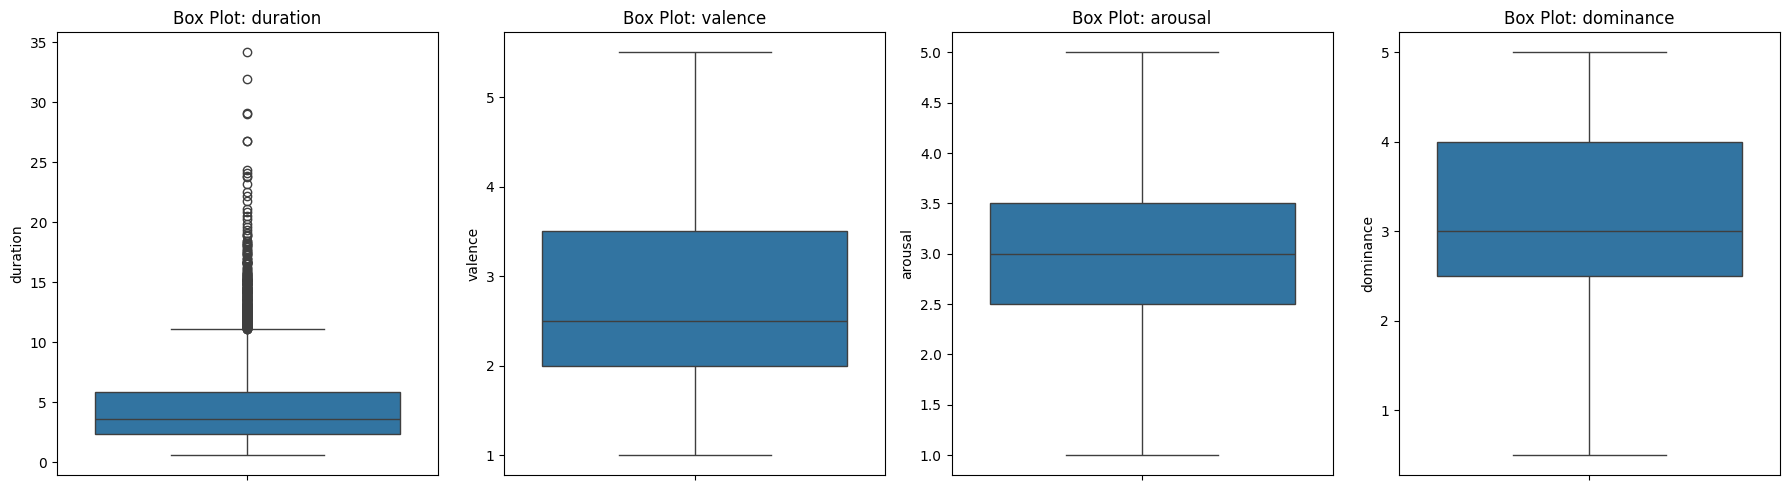

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Box plots for visual outlier inspection
numeric_cols = ['duration', 'valence', 'arousal', 'dominance']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df_emotions_only[col], ax=axes[i])
    axes[i].set_title(f'Box Plot: {col}')
plt.tight_layout()
plt.show()

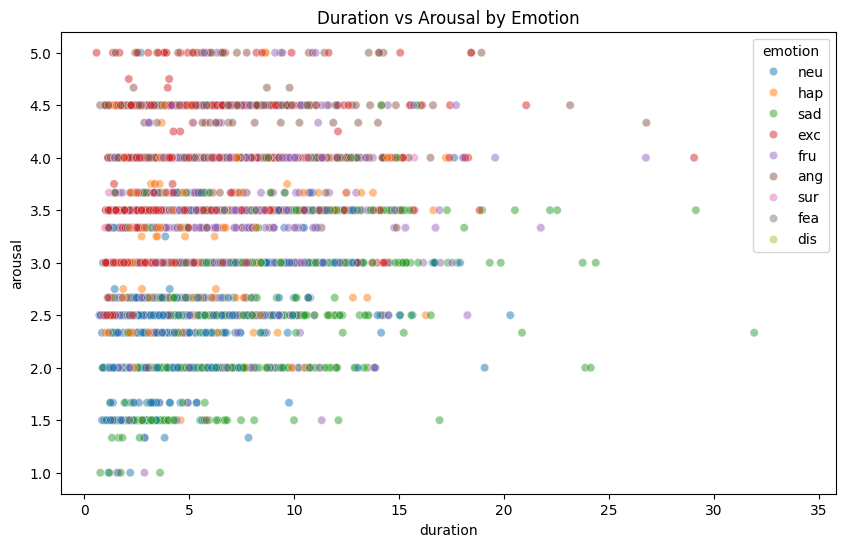

In [48]:
# Scatter plot: duration vs arousal, colored by emotion helps spot extreme combos visually
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_emotions_only, x='duration', y='arousal', hue='emotion', alpha=0.5)
plt.title('Duration vs Arousal by Emotion')
plt.show()

Univariate Analysis

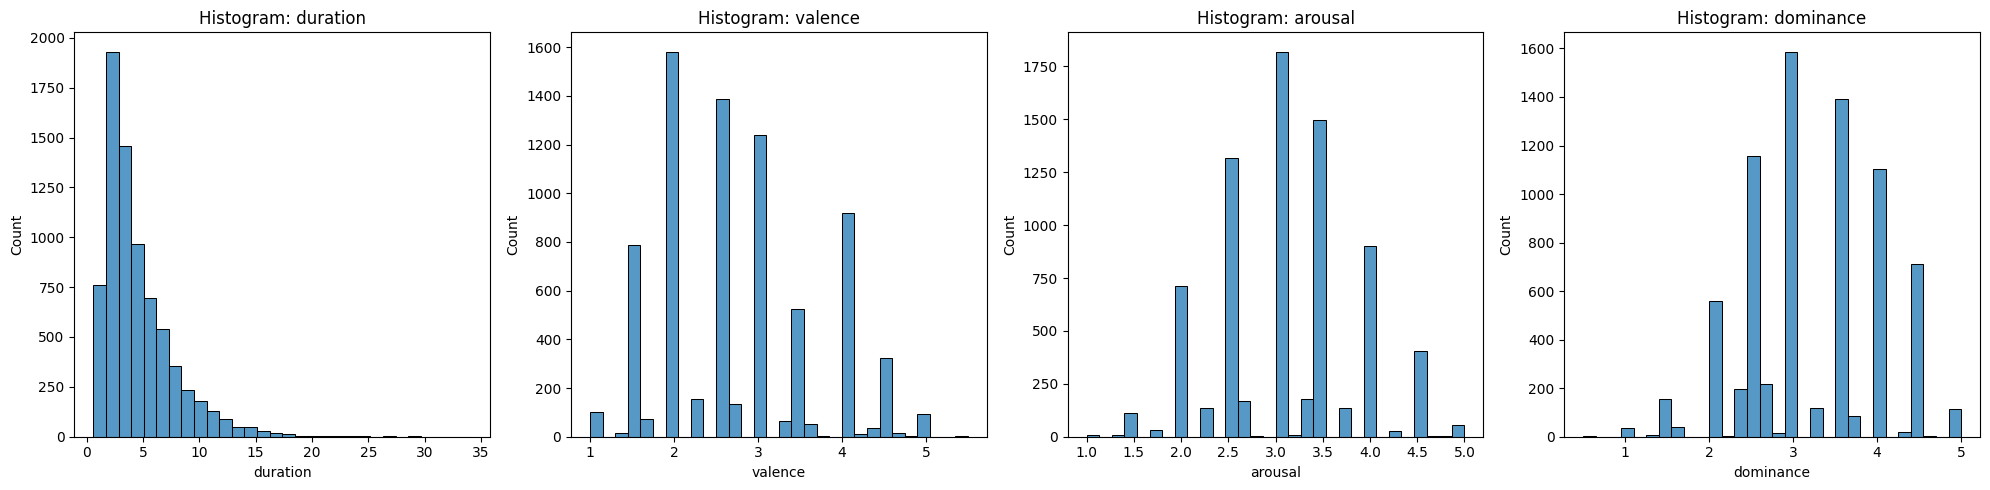

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms for numeric variables
numeric_cols = ['duration', 'valence', 'arousal', 'dominance']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(numeric_cols):
    sns.histplot(df_emotions_only[col], bins=30, kde=False, ax=axes[i])
    axes[i].set_title(f'Histogram: {col}')
plt.tight_layout()
plt.show()

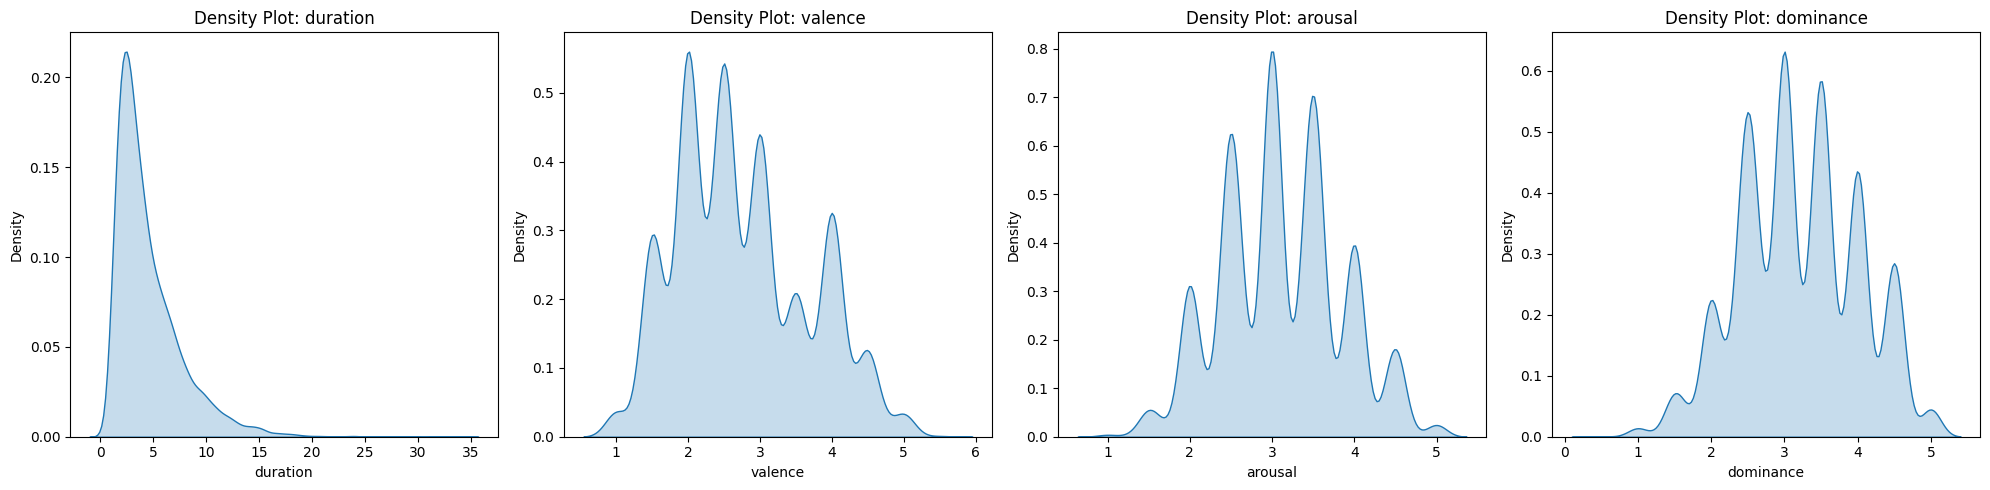

In [50]:
# Density plots (KDE) for the same numeric variables for smoother view of distribution shape
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(numeric_cols):
    sns.kdeplot(df_emotions_only[col], fill=True, ax=axes[i])
    axes[i].set_title(f'Density Plot: {col}')
plt.tight_layout()
plt.show()

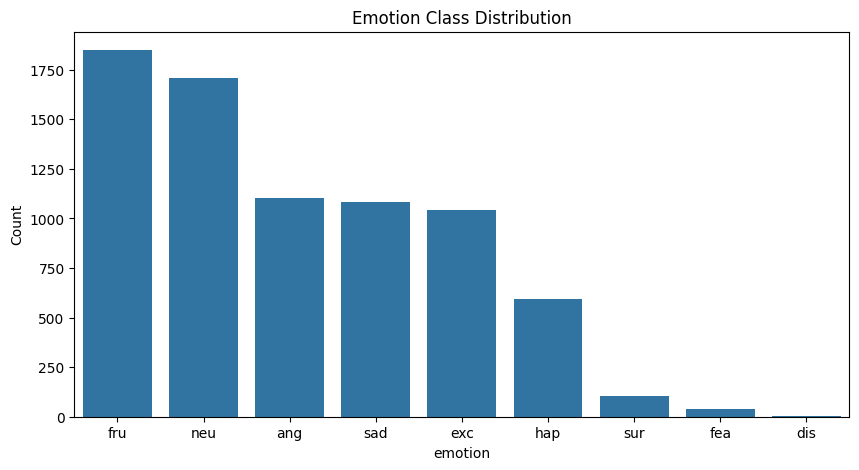

In [51]:
# Bar chart: emotion category frequency (the key categorical variable)
plt.figure(figsize=(10, 5))
order = df_emotions_only['emotion'].value_counts().index
sns.countplot(data=df_emotions_only, x='emotion', order=order)
plt.title('Emotion Class Distribution')
plt.ylabel('Count')
plt.show()

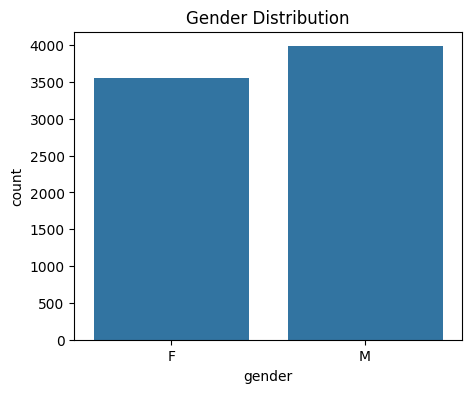

In [52]:
# Bar chart: gender distribution
plt.figure(figsize=(5, 4))
sns.countplot(data=df_emotions_only, x='gender')
plt.title('Gender Distribution')
plt.show()

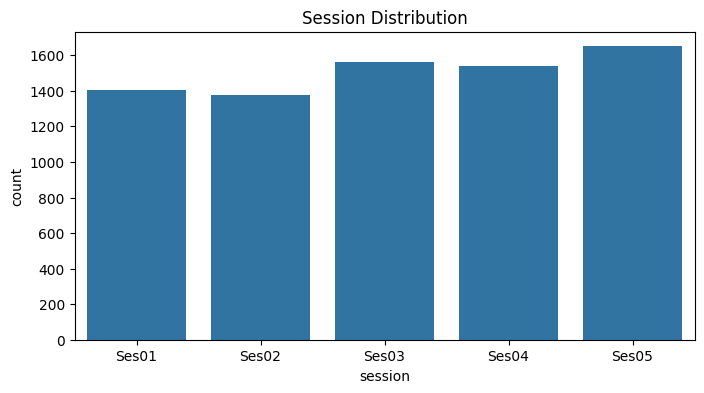

In [53]:
# Bar chart: session distribution : check if data is roughly even across sessions
plt.figure(figsize=(8, 4))
sns.countplot(data=df_emotions_only, x='session', order=sorted(df_emotions_only['session'].unique()))
plt.title('Session Distribution')
plt.show()

bivariate analysis

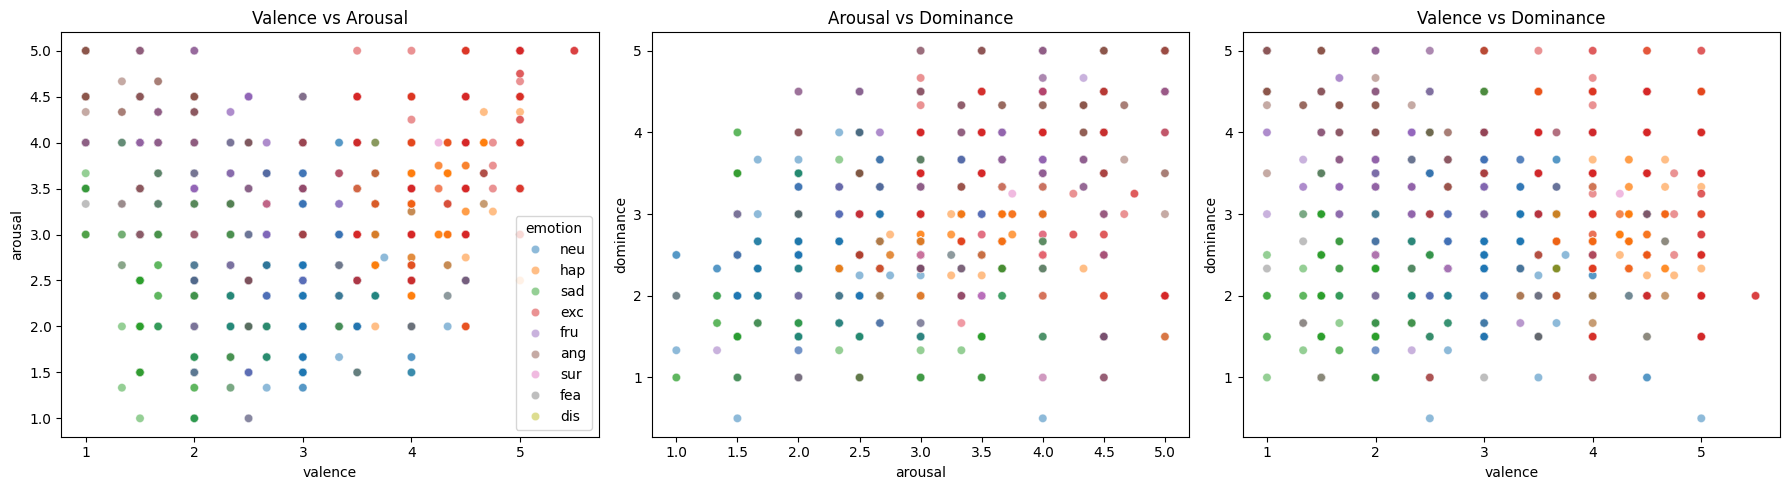

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plots between pairs of numeric variables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df_emotions_only, x='valence', y='arousal', hue='emotion', alpha=0.5, ax=axes[0])
axes[0].set_title('Valence vs Arousal')

sns.scatterplot(data=df_emotions_only, x='arousal', y='dominance', hue='emotion', alpha=0.5, ax=axes[1], legend=False)
axes[1].set_title('Arousal vs Dominance')

sns.scatterplot(data=df_emotions_only, x='valence', y='dominance', hue='emotion', alpha=0.5, ax=axes[2], legend=False)
axes[2].set_title('Valence vs Dominance')

plt.tight_layout()
plt.show()

           duration   valence   arousal  dominance
duration   1.000000 -0.106893  0.233143   0.258612
valence   -0.106893  1.000000  0.003214  -0.197395
arousal    0.233143  0.003214  1.000000   0.570420
dominance  0.258612 -0.197395  0.570420   1.000000


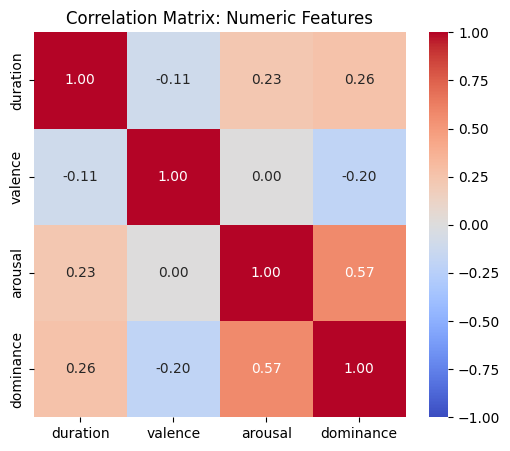

In [55]:
# Correlation matrix (Pearson) between numeric variables
numeric_cols = ['duration', 'valence', 'arousal', 'dominance']
corr_matrix = df_emotions_only[numeric_cols].corr()
print(corr_matrix)

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix: Numeric Features')
plt.show()

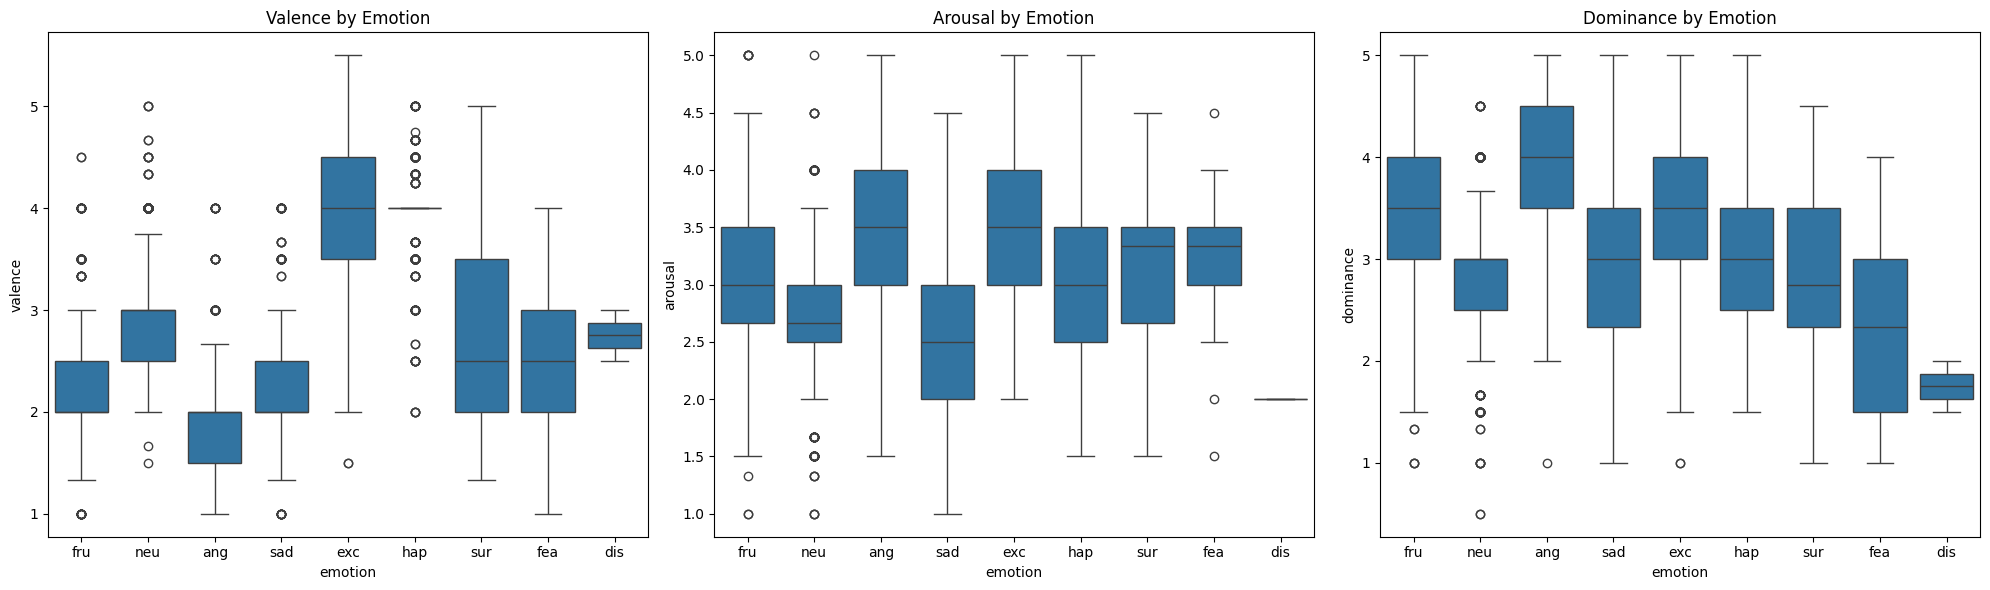

In [56]:
# Grouped box plots: how numeric variables vary across emotion categories
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

order = df_emotions_only['emotion'].value_counts().index

sns.boxplot(data=df_emotions_only, x='emotion', y='valence', order=order, ax=axes[0])
axes[0].set_title('Valence by Emotion')

sns.boxplot(data=df_emotions_only, x='emotion', y='arousal', order=order, ax=axes[1])
axes[1].set_title('Arousal by Emotion')

sns.boxplot(data=df_emotions_only, x='emotion', y='dominance', order=order, ax=axes[2])
axes[2].set_title('Dominance by Emotion')

plt.tight_layout()
plt.show()

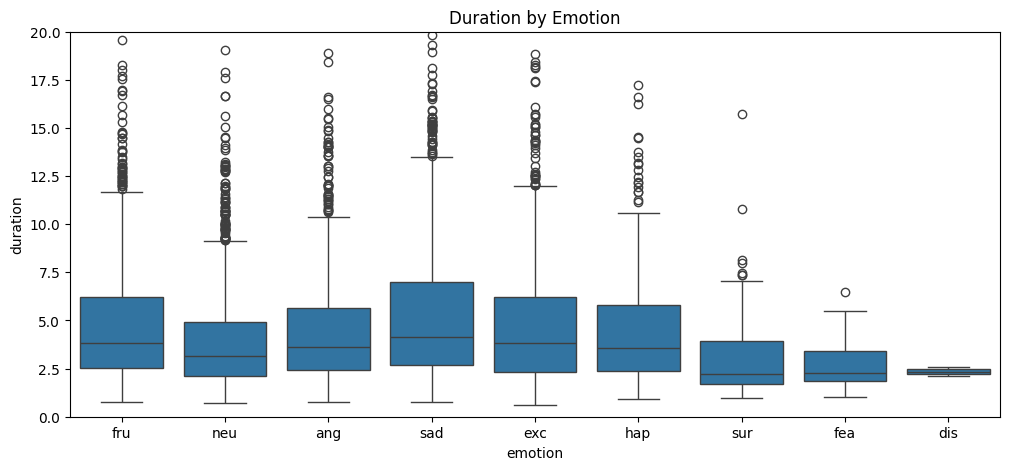

In [57]:
# Grouped box plot: duration by emotion do certain emotions run longer? (echoes what we saw in outlier detection)
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_emotions_only, x='emotion', y='duration', order=order)
plt.title('Duration by Emotion')
plt.ylim(0, 20)  # zoom in, since a few long outliers would otherwise squash the view
plt.show()

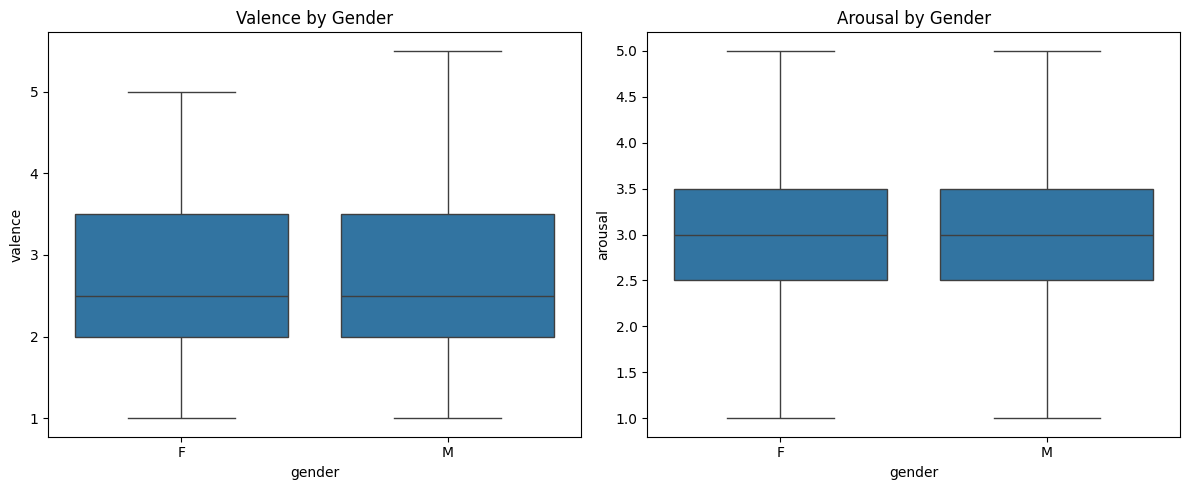

In [58]:
# Grouped comparison: valence/arousal by gender
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_emotions_only, x='gender', y='valence', ax=axes[0])
axes[0].set_title('Valence by Gender')
sns.boxplot(data=df_emotions_only, x='gender', y='arousal', ax=axes[1])
axes[1].set_title('Arousal by Gender')
plt.tight_layout()
plt.show()

multivariate analysis

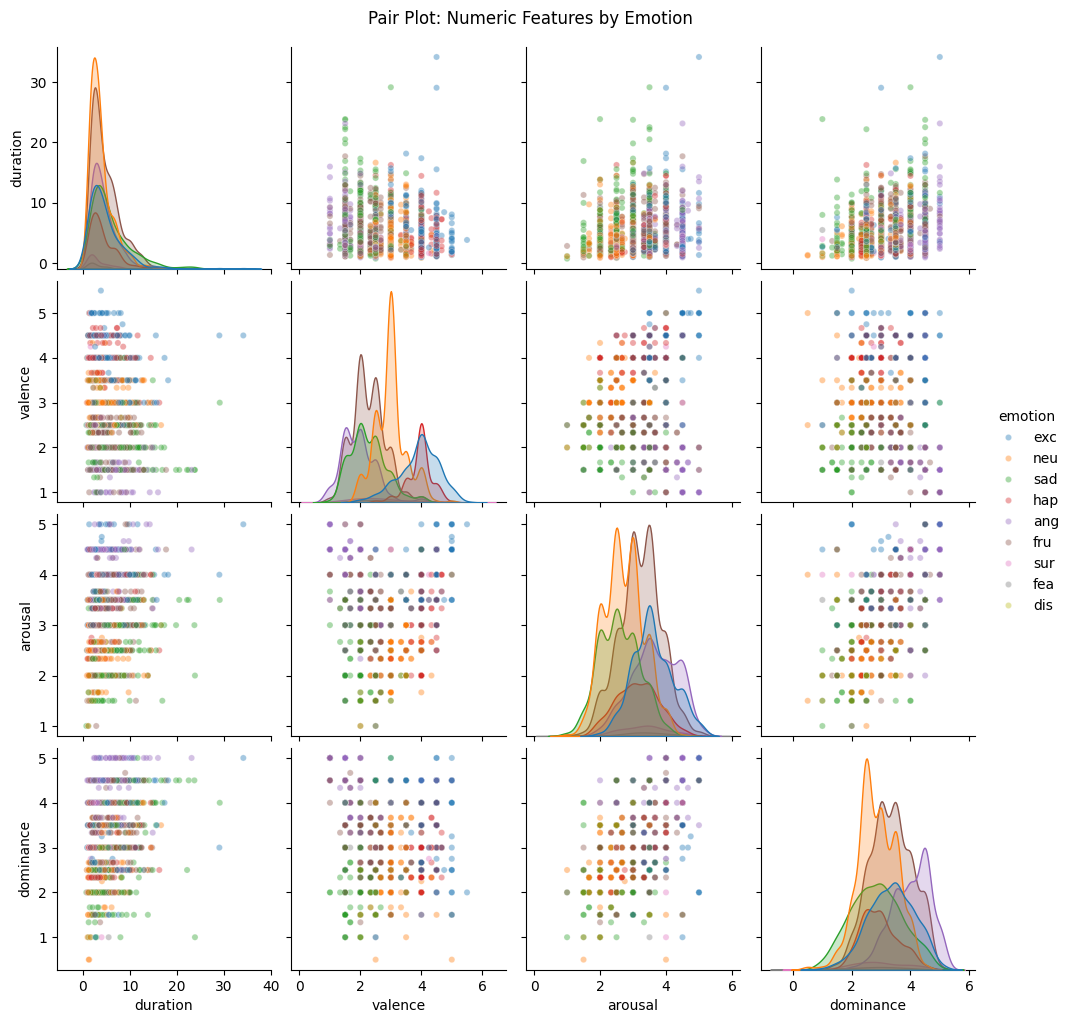

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pair plot: all numeric variables against each other, colored by emotion
# (sampling a subset if the full dataset renders too slowly)
sample_df = df_emotions_only.sample(min(2000, len(df_emotions_only)), random_state=42)

sns.pairplot(
    sample_df,
    vars=['duration', 'valence', 'arousal', 'dominance'],
    hue='emotion',
    plot_kws={'alpha': 0.4, 's': 20},
    diag_kind='kde'
)
plt.suptitle('Pair Plot: Numeric Features by Emotion', y=1.02)
plt.show()

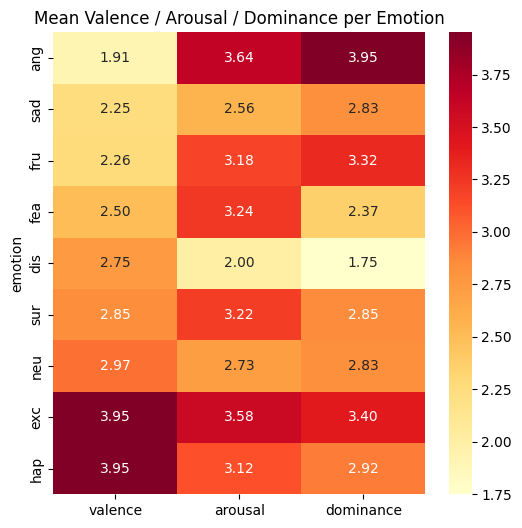

In [60]:
# Heatmap: mean valence/arousal/dominance per emotion category
# This condenses the multivariate relationship (emotion x 3 numeric dims) into one view
pivot = df_emotions_only.groupby('emotion')[['valence', 'arousal', 'dominance']].mean()
pivot = pivot.sort_values('valence')

plt.figure(figsize=(6, 6))
sns.heatmap(pivot, annot=True, cmap='YlOrRd', fmt='.2f')
plt.title('Mean Valence / Arousal / Dominance per Emotion')
plt.show()

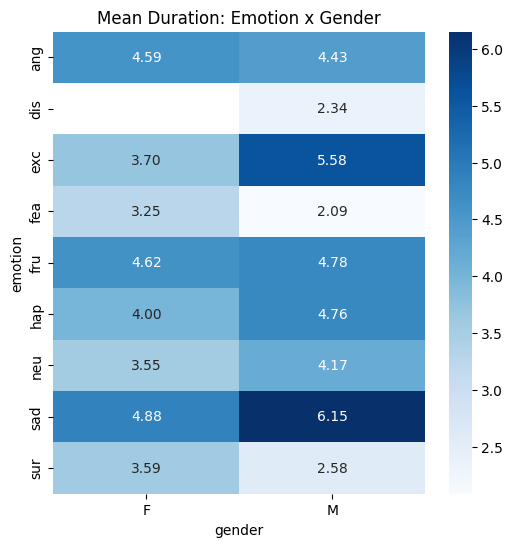

In [61]:
# Heatmap: mean duration per emotion x gender (2 categorical dims x 1 numeric)
pivot2 = df_emotions_only.pivot_table(values='duration', index='emotion', columns='gender', aggfunc='mean')

plt.figure(figsize=(6, 6))
sns.heatmap(pivot2, annot=True, cmap='Blues', fmt='.2f')
plt.title('Mean Duration: Emotion x Gender')
plt.show()

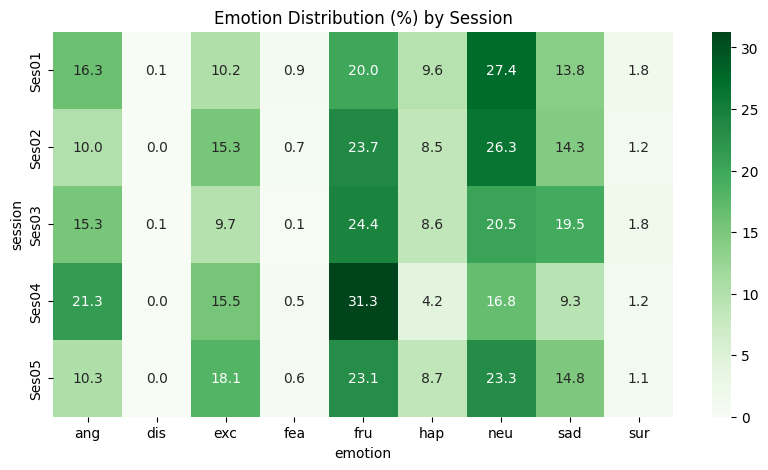

In [62]:
# Heatmap: emotion distribution across sessions (checks if certain sessions skew toward certain emotions)
pivot3 = pd.crosstab(df_emotions_only['session'], df_emotions_only['emotion'], normalize='index') * 100

plt.figure(figsize=(10, 5))
sns.heatmap(pivot3, annot=True, cmap='Greens', fmt='.1f')
plt.title('Emotion Distribution (%) by Session')
plt.show()

feature insights

In [63]:
import numpy as np
from scipy import stats

# Skewness and kurtosis for each numeric feature
numeric_cols = ['duration', 'valence', 'arousal', 'dominance']

print("Skewness (0 = symmetric, >1 or <-1 = highly skewed):")
for col in numeric_cols:
    print(f"  {col}: {df_emotions_only[col].skew():.3f}")

print("\nKurtosis (0 = normal-like tails, higher = heavier tails/more outliers):")
for col in numeric_cols:
    print(f"  {col}: {df_emotions_only[col].kurt():.3f}")

Skewness (0 = symmetric, >1 or <-1 = highly skewed):
  duration: 1.994
  valence: 0.432
  arousal: 0.096
  dominance: -0.007

Kurtosis (0 = normal-like tails, higher = heavier tails/more outliers):
  duration: 6.631
  valence: -0.623
  arousal: -0.402
  dominance: -0.500


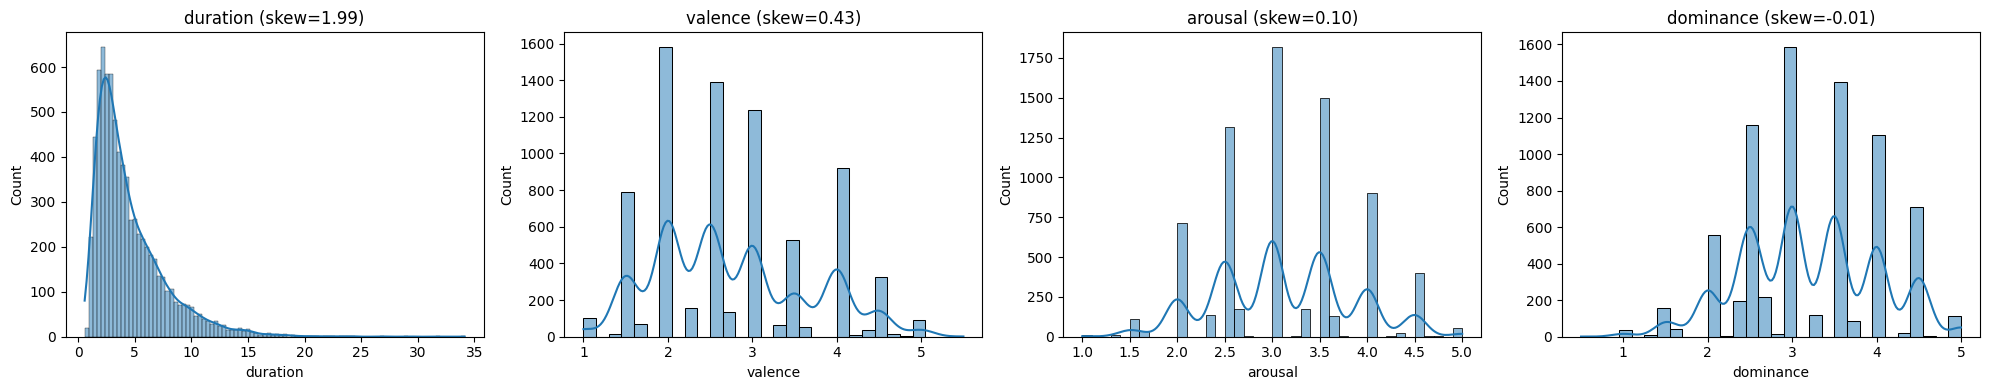

In [64]:
# Visualize skewness directly
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, col in enumerate(numeric_cols):
    sns.histplot(df_emotions_only[col], kde=True, ax=axes[i])
    skew_val = df_emotions_only[col].skew()
    axes[i].set_title(f'{col} (skew={skew_val:.2f})')
plt.tight_layout()
plt.show()

In [65]:
# Multi-collinearity check: correlation matrix (already computed) + VIF (Variance Inflation Factor)
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_emotions_only[numeric_cols].dropna()

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

     feature        VIF
0   duration   3.345222
1    valence   6.930026
2    arousal  26.912274
3  dominance  21.936382


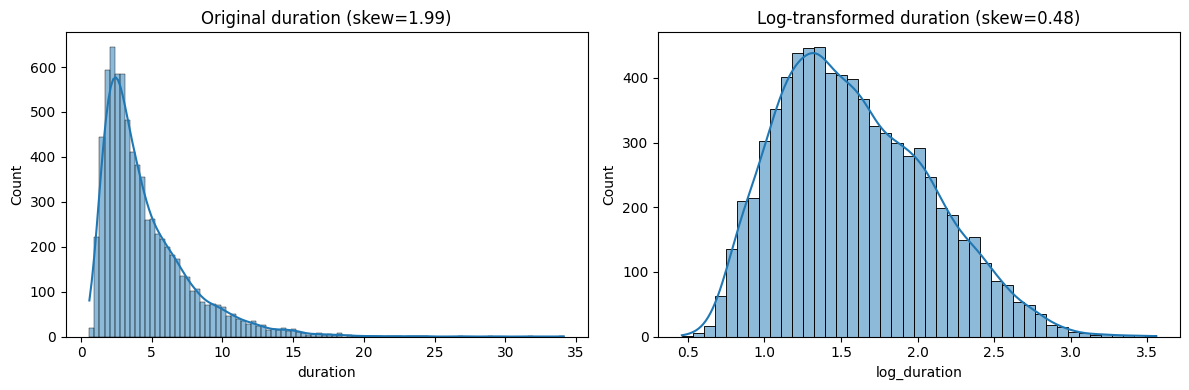

In [66]:
# Log transform on duration to fix right-skew - check if it helps normalize the distribution
df_emotions_only['log_duration'] = np.log1p(df_emotions_only['duration'])  # log1p handles any zero/small values safely

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_emotions_only['duration'], kde=True, ax=axes[0])
axes[0].set_title(f"Original duration (skew={df_emotions_only['duration'].skew():.2f})")

sns.histplot(df_emotions_only['log_duration'], kde=True, ax=axes[1])
axes[1].set_title(f"Log-transformed duration (skew={df_emotions_only['log_duration'].skew():.2f})")

plt.tight_layout()
plt.show()